In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rafsunahmad/skin-disease-text-classification")

print("Path to dataset files:", path)

100%|██████████| 11.0k/11.0k [00:00<00:00, 18.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rafsunahmad/skin-disease-text-classification/versions/1


In [ ]:
# Skin Disease Text Classification
# Classify Various Skin Disease

In [ ]:
import os

print(os.listdir(path))


['Skin_text_classifier.csv']


In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, "skin_text_classifier.csv")

print(file_path)
print(os.path.exists(file_path))

/root/.cache/kagglehub/datasets/rafsunahmad/skin-disease-text-classification/versions/1/skin_text_classifier.csv
False


In [ ]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/rafsunahmad/skin-disease-text-classification/versions/1/Skin_text_classifier.csv


In [ ]:
import pandas as pd

file_path = "/root/.cache/kagglehub/datasets/rafsunahmad/skin-disease-text-classification/versions/1/Skin_text_classifier.csv"

df = pd.read_csv(file_path)

df.head()

,Disease name,Text
0,Vitiligo,"""I've had these light patches on my neck and f..."
1,Scabies,"""Doctor, I've noticed these small, red bumps o..."
2,Vitiligo,"""Doctor, I noticed a pale patch around my knee..."
3,Hives (Urticaria),"Hives, also known as urticaria, typically pres..."
4,Folliculitis,"""I have these small, hard bumps on my buttocks..."


In [ ]:
print("Shape:",df.shape)

print("\nColumn names:")
print(df.columns)

print("\nMisssing values:")
print(df.isnull().sum())

print("\nNumber of diseases:")
print (df["Disease name"].nunique())

print("\nDiseases:")
print(df["Disease name"].unique())


Shape: (143, 2)

Column names:
Index(['Disease name', 'Text'], dtype='object')

Misssing values:
Disease name    0
Text            0
dtype: int64

Number of diseases:
13

Diseases:
['Vitiligo' 'Scabies' 'Hives (Urticaria)' 'Folliculitis' 'Eczema'
 'Ringworm (Tinea Corporis)' "Athlete's Foot (Tinea Pedis)" 'Rosacea'
 'Psoriasis' 'Shingles (Herpes Zoster)' 'Impetigo' 'Contact Dermatitis'
 'Acne']


In [ ]:
print(df["Disease name"].value_counts())


Disease name
Vitiligo                        11
Scabies                         11
Hives (Urticaria)               11
Folliculitis                    11
Eczema                          11
Ringworm (Tinea Corporis)       11
Athlete's Foot (Tinea Pedis)    11
Rosacea                         11
Psoriasis                       11
Shingles (Herpes Zoster)        11
Impetigo                        11
Contact Dermatitis              11
Acne                            11
Name: count, dtype: int64


In [ ]:
#Separate input and target

X =df["Text"]
y=df["Disease name"]

print ("Input(X):")
print(X.head())

print("\nTarget(y):")
print(y.head())

Input(X):
0    "I've had these light patches on my neck and f...
1    "Doctor, I've noticed these small, red bumps o...
2    "Doctor, I noticed a pale patch around my knee...
3    Hives, also known as urticaria, typically pres...
4    "I have these small, hard bumps on my buttocks...
Name: Text, dtype: object

Target(y):
0             Vitiligo
1              Scabies
2             Vitiligo
3    Hives (Urticaria)
4         Folliculitis
Name: Disease name, dtype: object


In [ ]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training samples:",
      len(X_train))
print("Testing samples:",len(X_test))



Training samples: 114
Testing samples: 29


In [ ]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (114, 901)
Testing TF-IDF shape: (29, 901)


In [ ]:
#Train your first model: Multiclass Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
#PREDICTION
y_pred = model.predict(X_test_tfidf)

print("Predicted diseases:")
print(y_pred)

Predicted diseases:
["Athlete's Foot (Tinea Pedis)" 'Eczema' 'Impetigo' 'Rosacea'
 'Contact Dermatitis' 'Eczema' 'Acne' 'Impetigo' 'Contact Dermatitis'
 'Hives (Urticaria)' 'Acne' 'Folliculitis' 'Vitiligo'
 "Athlete's Foot (Tinea Pedis)" 'Vitiligo' 'Ringworm (Tinea Corporis)'
 'Impetigo' 'Shingles (Herpes Zoster)' 'Psoriasis' 'Folliculitis'
 'Scabies' 'Folliculitis' 'Psoriasis' 'Shingles (Herpes Zoster)'
 'Psoriasis' 'Scabies' 'Psoriasis' 'Acne' 'Acne']


In [ ]:
# Import evaluation metrics from Scikit-learn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Calculate weighted precision for all 13 disease classes
precision = precision_score(y_test, y_pred, average='weighted')

# Calculate weighted recall for all 13 disease classes
recall = recall_score(y_test, y_pred, average='weighted')

# Calculate weighted F1-score for all 13 disease classes
f1 = f1_score(y_test, y_pred, average='weighted')

# Display the evaluation results
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.6206896551724138
Precision: 0.6666666666666666
Recall   : 0.6206896551724138
F1 Score : 0.6137931034482759


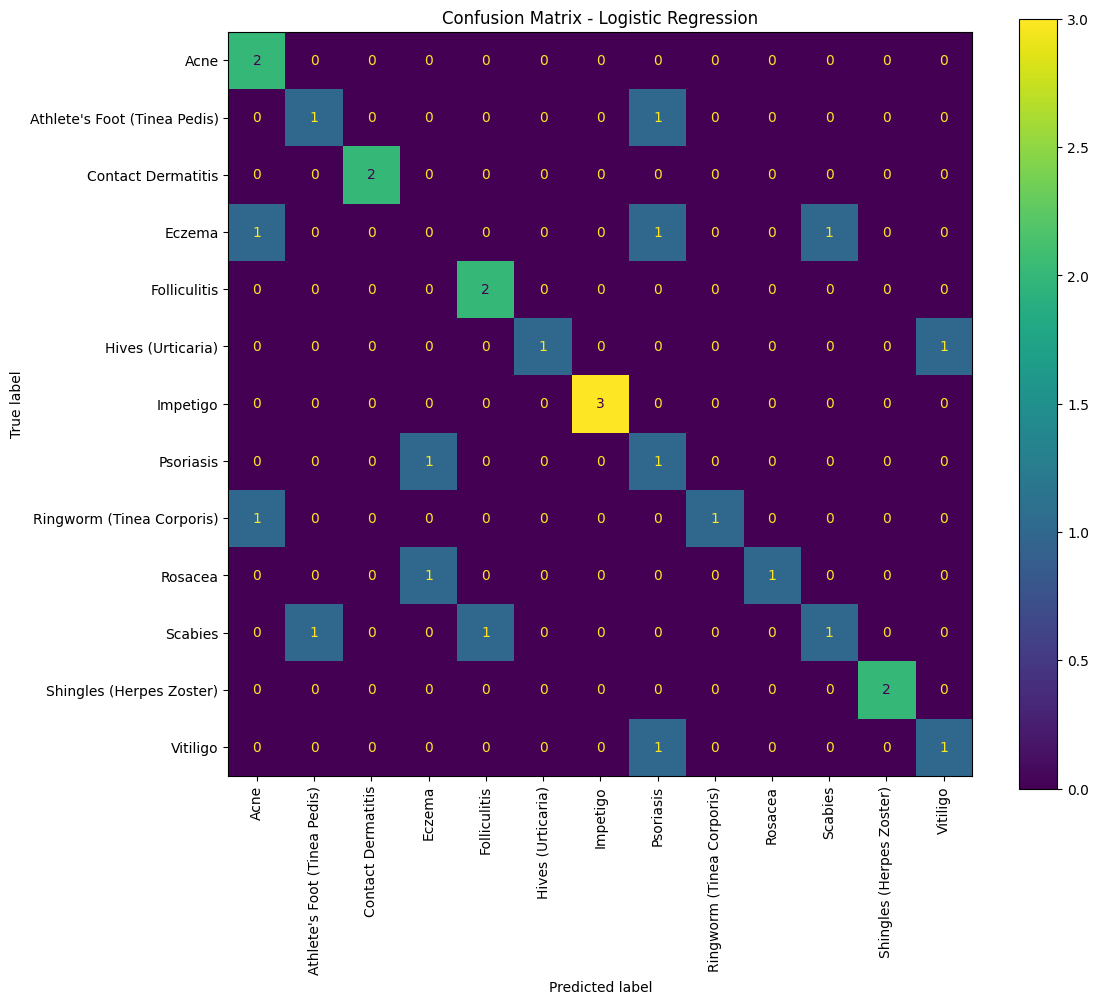

In [ ]:
# Import confusion matrix and display functions
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Create the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

#Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_)

#Set the figure size
fig, ax = plt.subplots(figsize=(12, 10))

#PPlot the confusion matrix
disp.plot(ax=ax, xticks_rotation=90)

#Add title
plt.title("Confusion Matrix - Logistic Regression")

#Display the plot
plt.show()

In [ ]:
# Classification Report

from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                              precision    recall  f1-score   support

                        Acne       0.50      1.00      0.67         2
Athlete's Foot (Tinea Pedis)       0.50      0.50      0.50         2
          Contact Dermatitis       1.00      1.00      1.00         2
                      Eczema       0.00      0.00      0.00         3
                Folliculitis       0.67      1.00      0.80         2
           Hives (Urticaria)       1.00      0.50      0.67         2
                    Impetigo       1.00      1.00      1.00         3
                   Psoriasis       0.25      0.50      0.33         2
   Ringworm (Tinea Corporis)       1.00      0.50      0.67         2
                     Rosacea       1.00      0.50      0.67         2
                     Scabies       0.50      0.33      0.40         3
    Shingles (Herpes Zoster)       1.00      1.00      1.00         2
                    Vitiligo       0.50      0.50      0.50       

In [ ]:
# Naive Bayes Model

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Create the model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

# Predict on test data
y_pred_nb = nb_model.predict(X_test_tfidf)

# Calculate accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)
print("Naive Bayes Accuracy (%):", accuracy_nb * 100)

Naive Bayes Accuracy: 0.5862068965517241
Naive Bayes Accuracy (%): 58.620689655172406


In [ ]:
#Support Vector Machine (SVM)

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Create the model
svm_model = LinearSVC()

# Train the model
svm_model.fit(X_train_tfidf, y_train)

# Predict on test data
y_pred_svm = svm_model.predict(X_test_tfidf)

# Calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)
print("SVM Accuracy (%):", accuracy_svm * 100)

SVM Accuracy: 0.6896551724137931
SVM Accuracy (%): 68.96551724137932


In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train_tfidf, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test_tfidf)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest Accuracy (%):", accuracy_rf * 100)

Random Forest Accuracy: 0.5862068965517241
Random Forest Accuracy (%): 58.620689655172406


In [ ]:
# SVM with RBF Kernel

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Create SVM model with RBF kernel
svm_rbf = SVC(kernel='rbf', C=10, gamma='scale')

# Train the model
svm_rbf.fit(X_train_tfidf, y_train)

# Predict on test data
y_pred_svm_rbf = svm_rbf.predict(X_test_tfidf)

# Calculate accuracy
accuracy_rbf = accuracy_score(y_test, y_pred_svm_rbf)

print("SVM RBF Accuracy:", accuracy_rbf)
print("SVM RBF Accuracy (%):", accuracy_rbf * 100)

SVM RBF Accuracy: 0.6206896551724138
SVM RBF Accuracy (%): 62.06896551724138


In [ ]:
# Tune C and Gamma for RBF SVM

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

results = []

for C in [0.1, 1, 10, 100]:
    for gamma in ['scale', 0.01, 0.1, 1]:

        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(X_train_tfidf, y_train)

        pred = model.predict(X_test_tfidf)
        acc = accuracy_score(y_test, pred)

        results.append((C, gamma, acc))

        print("C:", C, "| Gamma:", gamma,
              "| Accuracy:", round(acc * 100, 2), "%")

C: 0.1 | Gamma: scale | Accuracy: 44.83 %
C: 0.1 | Gamma: 0.01 | Accuracy: 44.83 %
C: 0.1 | Gamma: 0.1 | Accuracy: 44.83 %
C: 0.1 | Gamma: 1 | Accuracy: 44.83 %
C: 1 | Gamma: scale | Accuracy: 48.28 %
C: 1 | Gamma: 0.01 | Accuracy: 44.83 %
C: 1 | Gamma: 0.1 | Accuracy: 44.83 %
C: 1 | Gamma: 1 | Accuracy: 48.28 %
C: 10 | Gamma: scale | Accuracy: 62.07 %
C: 10 | Gamma: 0.01 | Accuracy: 44.83 %
C: 10 | Gamma: 0.1 | Accuracy: 62.07 %
C: 10 | Gamma: 1 | Accuracy: 62.07 %
C: 100 | Gamma: scale | Accuracy: 62.07 %
C: 100 | Gamma: 0.01 | Accuracy: 62.07 %
C: 100 | Gamma: 0.1 | Accuracy: 62.07 %
C: 100 | Gamma: 1 | Accuracy: 62.07 %
